# Purpose

Design NPS resin for new [Elegoo Mars 4 Ultra](https://us.elegoo.com/products/elegoo-mars-4-ultra-msla-resin-3d-printer-with-9k-mono-lcd#specification) LCD 3D printer, which has 18 &mu;m pixel size and 405 nm LED source. Use measured LED spectrum, `Elegoo_405nm_Mars4_Ultra_2024-05-16`.

# Imports

In [1]:
from pathlib import Path
import typing

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
import matplotlib
#%matplotlib widget
%matplotlib inline

from scipy.optimize import curve_fit
import scipy.integrate as integrate

import spectra.data as data
from spectra.resin import ResinConstituentAbsorber, ResinConstituentMonomer, Resin
from spectra.sourcespectrum import SourceSpectrum
from spectra.utilities import ArrayParams
from spectra.irradiance import Irradiance
from spectra.normalizeddose import NormalizedDose

In [2]:
import sys
!{sys.executable} --version

Python 3.12.2


# Available spectrum data

In [3]:
data.sources

{'365nm_visitech_with_50mm_asahi_filter_2018-11-22': <spectra.sourcespectrum.SourceSpectrum at 0x12fac5880>,
 'Asiga_405nm_100um_fiber-2016-12-14': <spectra.sourcespectrum.SourceSpectrum at 0x12fac5940>,
 'Elegoo_405nm_Mars4_Ultra_2024-05-16': <spectra.sourcespectrum.SourceSpectrum at 0x12fac59d0>,
 'HR1_385nm_100um_fiber-2016-12-14': <spectra.sourcespectrum.SourceSpectrum at 0x12fac5a30>,
 'HR2_385nm_2020-03-23': <spectra.sourcespectrum.SourceSpectrum at 0x10fe5de80>,
 'HR3.2_365nm_370nm_short_pass_filter-2019-12-31': <spectra.sourcespectrum.SourceSpectrum at 0x12fac5910>,
 'HR3.2_365nm_no_filter-2019-12-31': <spectra.sourcespectrum.SourceSpectrum at 0x12fac5b20>,
 'HR3.3_365nm_370nm_short_pass_filter-2020-03-23': <spectra.sourcespectrum.SourceSpectrum at 0x12fac5b80>,
 'HR3.3_365nm_no_filter-2020-03-23': <spectra.sourcespectrum.SourceSpectrum at 0x12fac5be0>,
 'HR3.3_365nm_through_tray_370nm_short_pass_filter-2020-03-23': <spectra.sourcespectrum.SourceSpectrum at 0x12fac5c40>,
 'HR3.

In [4]:
data.absorbers

{'avobenzone_in_PEGDA_2017-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x12fac43b0>,
 'avobenzone_in_PEGDA_2020-01-20': <spectra.absorberspectrum.AbsorberSpectrum at 0x128747f80>,
 'benetex_obplus_in PEGDA_2017-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x10feeae10>,
 'bls99-2_in_PEGDA_2017-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x12fac4590>,
 'ideal_uniform_absorber': <spectra.absorberspectrum.AbsorberSpectrum at 0x12fac4560>,
 'martius_yellow_in PEGDA_2020-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x12fac4770>,
 'nps_in_PEGDA_2017-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x10ff069c0>,
 'octocrylene_in_PEGDA_2017-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x12fac4860>,
 'phenazine_in_PEGDA_2017-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x12fac4a10>,
 'salicylaldehyde_in_PEGDA_2017-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x12fac4b00>,
 'sudanI_in_PEGDA_2017-04-13': <spectra.absorberspectru

In [5]:
data.monomers

{'HDDA': Monomer(/Users/nordin/Documents/Projects/3D_printer_spectra_repos/3dprinter_spectra_and_tools/spectra/data/monomers/hdda.json),
 'Ideal': Monomer(/Users/nordin/Documents/Projects/3D_printer_spectra_repos/3dprinter_spectra_and_tools/spectra/data/monomers/ideal.json),
 'PEGDA': Monomer(/Users/nordin/Documents/Projects/3D_printer_spectra_repos/3dprinter_spectra_and_tools/spectra/data/monomers/pegda.json),
 'TET': Monomer(/Users/nordin/Documents/Projects/3D_printer_spectra_repos/3dprinter_spectra_and_tools/spectra/data/monomers/tet.json)}

# Elegoo 405 nm LED spectrum

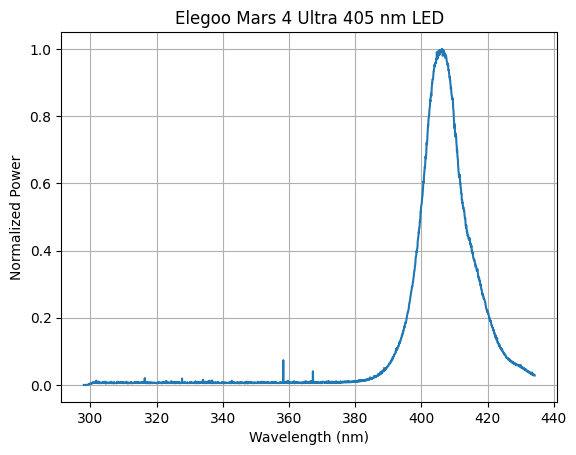

In [7]:
source = data.sources['Elegoo_405nm_Mars4_Ultra_2024-05-16']

fig, ax = plt.subplots()
ax.plot(source.wavelength, source.power)
ax.set_ylabel("Normalized Power")
ax.set_xlabel("Wavelength (nm)")
ax.set_title("Elegoo Mars 4 Ultra 405 nm LED")
ax.grid()

## Compare to other 405 nm LED spectra

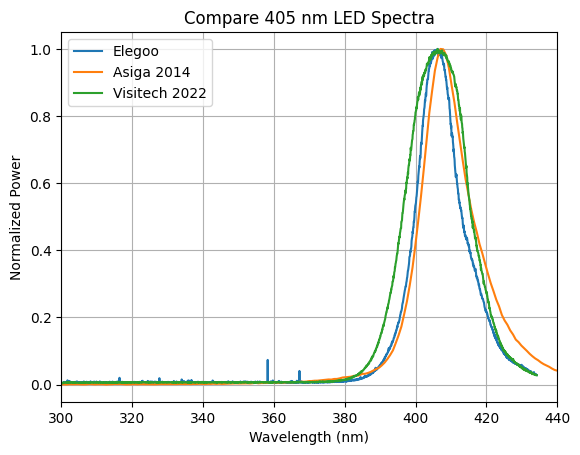

In [11]:
source_asiga = data.sources['Asiga_405nm_100um_fiber-2016-12-14']
source_visitech = data.sources['MR1_405nm_Visitech_unfiltered_2022-08-12']

fig, ax = plt.subplots()
ax.plot(source.wavelength, source.power, label="Elegoo")
ax.plot(source_asiga.wavelength, source_asiga.power, label="Asiga 2014")
ax.plot(source_visitech.wavelength, source_visitech.power, label="Visitech 2022")
ax.set_xlim(300, 440)
ax.set_ylabel("Normalized Power")
ax.set_xlabel("Wavelength (nm)")
ax.set_title("Compare 405 nm LED Spectra")
ax.legend()
ax.grid()

# Initialize parameters

## Resins

In [12]:
# Create resin
pegda = ResinConstituentMonomer(data.monomers['PEGDA'], 100)
nps_2p0 = ResinConstituentAbsorber(
    data.absorbers['nps_in_PEGDA_2017-04-13'],
    2.0
)
nps_1p0 = ResinConstituentAbsorber(
    data.absorbers['nps_in_PEGDA_2017-04-13'],
    1.0
)
nps_0p5 = ResinConstituentAbsorber(
    data.absorbers['nps_in_PEGDA_2017-04-13'],
    0.5
)
irgacure819 = ResinConstituentAbsorber(
    data.photoinitiators['irgacure819_in_PEGDA_2017-04-13'],
    1.0
)
resin_nps2p0 = Resin(monomers=pegda, absorbers=nps_2p0, photoinitiators=irgacure819)
resin_nps1p0 = Resin(monomers=pegda, absorbers=nps_1p0, photoinitiators=irgacure819)
resin_nps0p5 = Resin(monomers=pegda, absorbers=nps_0p5, photoinitiators=irgacure819)
print(f"{resin_nps2p0.name=}")
print(f"{resin_nps1p0.name=}")
print(f"{resin_nps0p5.name=}")

resin_nps2p0.name='PEG-100__NPS-2__Irg-1'
resin_nps1p0.name='PEG-100__NPS-1__Irg-1'
resin_nps0p5.name='PEG-100__NPS-0.5__Irg-1'


## Wavelength sampling array parameters

In [13]:
wavelength_array_parameters = ArrayParams(300, 440, 401)

# Calculations

In [14]:
irradiance_nps2p0 = Irradiance(source=source, resin=resin_nps2p0, wavelength_array_params=wavelength_array_parameters)
irradiance_nps1p0 = Irradiance(source=source, resin=resin_nps1p0, wavelength_array_params=wavelength_array_parameters)
irradiance_nps0p5 = Irradiance(source=source, resin=resin_nps0p5, wavelength_array_params=wavelength_array_parameters)

PEG-100__NPS-2__Irg-1


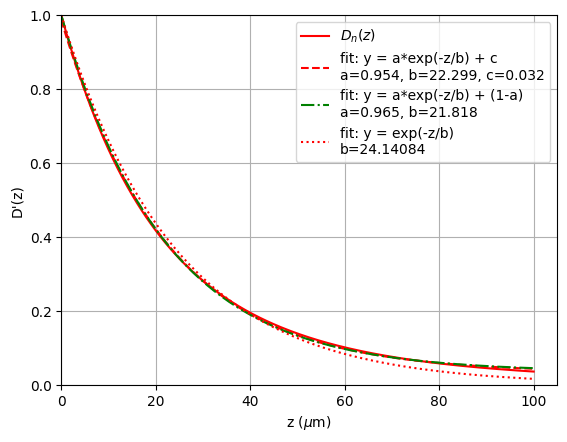

In [15]:
z_array_params = ArrayParams(0, 100, 201)

# Normalized dose
norm_dose_nps2p0 = NormalizedDose(irradiance=irradiance_nps2p0, z_array_params=z_array_params)
print(norm_dose_nps2p0.irradiance.resin.name)
norm_dose_nps2p0.plot();

PEG-100__NPS-1__Irg-1


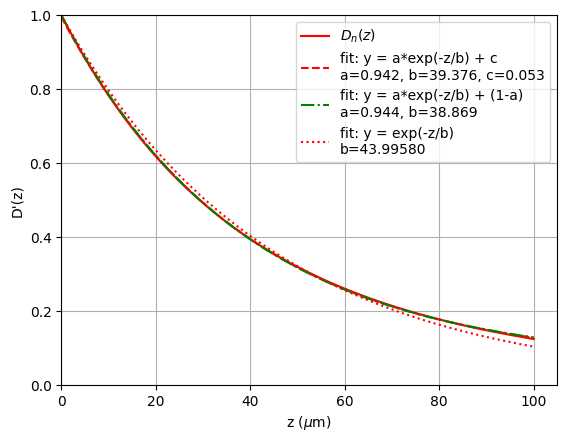

In [16]:
# Normalized dose
norm_dose_nps1p0 = NormalizedDose(irradiance=irradiance_nps1p0, z_array_params=z_array_params)
print(norm_dose_nps1p0.irradiance.resin.name)
norm_dose_nps1p0.plot();

PEG-100__NPS-0.5__Irg-1


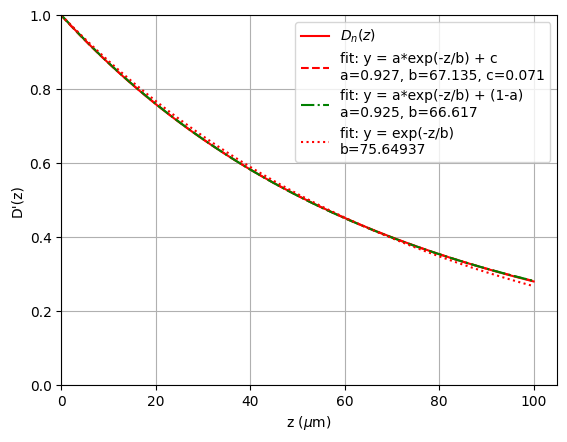

In [17]:
# Normalized dose
norm_dose_nps0p5 = NormalizedDose(irradiance=irradiance_nps0p5, z_array_params=z_array_params)
print(norm_dose_nps0p5.irradiance.resin.name)
norm_dose_nps0p5.plot();

# Optical penetration depth vs NPS concentration

In [18]:
pegda = ResinConstituentMonomer(data.monomers['PEGDA'], 100)
irgacure819 = ResinConstituentAbsorber(
    data.photoinitiators['irgacure819_in_PEGDA_2017-04-13'],
    1.0
)

nps_conc_values = np.linspace(0.5, 2.0, num=16)
optical_penetration_depth = []

for nps_conc in nps_conc_values:
    absorber = ResinConstituentAbsorber(
        data.absorbers['nps_in_PEGDA_2017-04-13'],
        nps_conc
    )
    resin = Resin(monomers=pegda, absorbers=absorber, photoinitiators=irgacure819)
    irradiance = Irradiance(source=source, resin=resin, wavelength_array_params=wavelength_array_parameters)
    norm_dose = NormalizedDose(irradiance=irradiance, z_array_params=z_array_params)
    optical_penetration_depth.append(norm_dose.a_b_model_params['b'])
    

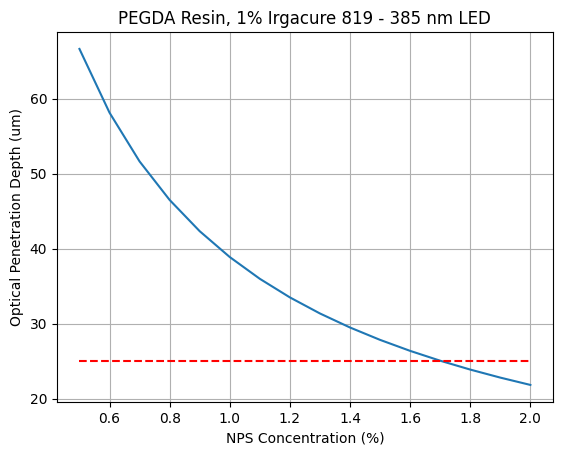

In [28]:
fig, ax = plt.subplots()
ax.plot(nps_conc_values, optical_penetration_depth)
ax.set_xlabel("NPS Concentration (%)")
ax.set_ylabel("Optical Penetration Depth (um)")
ax.set_title("PEGDA Resin, 1% Irgacure 819 - 385 nm LED")
ax.hlines(25, 0.5, 2.0, color="r", ls="--")
ax.grid()
plt.savefig("h_a_vs_NPS_concentration.png")

In [20]:
print("NPS conc. (%) | Optical penetration depth (um)")
print("----------------------------------------------")
for conc, h_a in zip(nps_conc_values, optical_penetration_depth):
    print(f"      {conc:0.2f}    |      {h_a:.2f}")

NPS conc. (%) | Optical penetration depth (um)
----------------------------------------------
      0.50    |      66.62
      0.60    |      58.12
      0.70    |      51.62
      0.80    |      46.48
      0.90    |      42.32
      1.00    |      38.87
      1.10    |      35.97
      1.20    |      33.49
      1.30    |      31.35
      1.40    |      29.48
      1.50    |      27.83
      1.60    |      26.36
      1.70    |      25.05
      1.80    |      23.86
      1.90    |      22.79
      2.00    |      21.82


# NPS 1.7%

PEG-100__NPS-1.7__Irg-1


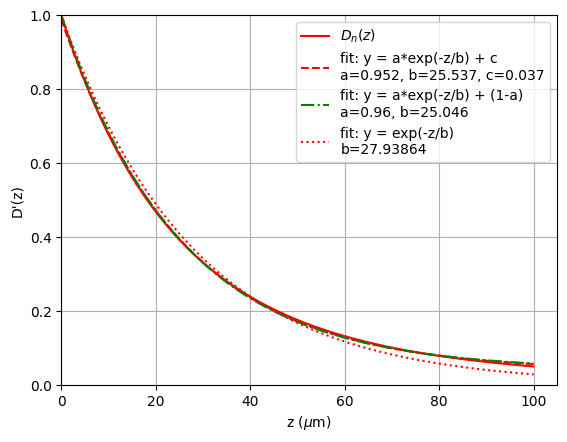

In [30]:
nps_1p7 = ResinConstituentAbsorber(
    data.absorbers['nps_in_PEGDA_2017-04-13'],
    1.7
)
resin_nps1p7 = Resin(monomers=pegda, absorbers=nps_1p7, photoinitiators=irgacure819)
# print(f"{resin_nps1p7.name=}")

irradiance_nps1p7 = Irradiance(source=source, resin=resin_nps1p7, wavelength_array_params=wavelength_array_parameters)

# Normalized dose
norm_dose_nps1p7 = NormalizedDose(irradiance=irradiance_nps1p7, z_array_params=z_array_params)
print(norm_dose_nps1p7.irradiance.resin.name)
norm_dose_nps1p7.plot();